# Data 1. NASA FLDAS (FEWS NET Land Data Assimilation System)
- 식량 안보 모니터링을 위해 NASA에서 제공하는 데이터
- 관측 데이터(CHIRPS 포함)를 기반으로 지면 모델(Noah 3.6.1) 시뮬레이션된 값
- 업데이트 주기 : monthly (매월 중순)
- 해상도 : 0.1 deg (약 11 km)

## 추출된 변수
- 아래 항목들을 Z-score (월별 평균을 빼고 표준편차로 나눈 값)로 변환(평년 기준은 1991~2020년)
- 추가로 직전 3개월, 6개월 관측 값도 함께 계산(state variable은 평균, flux variable은 누적합)
- State Variables
  - 평균 기온(Tair_f_tavg)
  - 지표면 복사 온도(RadT_tavg)
  - 토양 수분량(표층; ~10cm)(SoilMoi00_10cm_tavg)
  - 토양 수분량(뿌리층; 10~40cm)(SoilMoi10_40cm_tavg)
  - 토양 수분량(0~40cm)(SoilMoi00_40cm_tavg) : 위 2개 합한 값
- Flux Variables
  - 강수 플럭스(Rainf_f_tavg)
  - 증발산량(Evap_tavg)
  - 유출량(Surface)(Qs_tavg)
  - 유출량(Subsurface)(Qsb_tavg)
  - 총 유출량(Total_Runoff_tavg) : 위 2개 합한 값
  - 수분 균형(Water_Balance_tavg) : Rainf_f_tavg - Evap_tavg (SPEI 대체)

## GEE - Setting

In [1]:
import ee

# ⚠️ 중요: 아래에 사용 중인 Google Cloud Project ID를 입력해야 합니다.
# GEE Code Editor (https://code.earthengine.google.com/) 우측 상단 등에서 확인 가능합니다.
project_id = 'wfp-project-486106'

# GEE 인증 및 초기화
try:
    ee.Initialize(project=project_id)
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=project_id)

In [2]:
# ==========================================
# 🚀 사용자 설정 (Double Buffer Logic)
# ==========================================
ROI = ee.Geometry.Rectangle([25, -15, 52, 22]) # 동아프리카

# [1] 평년(Reference) 기간 설정 + 버퍼
REF_START = '1991-01-01'
REF_END = '2020-12-31'
REF_BUFFER_START = '1990-06-01' # 1991년 1월의 6개월 Rolling을 위한 버퍼

# [2] 분석(Target) 기간 설정 + 버퍼
TARGET_START = '2007-01-01'
TARGET_END = '2025-12-31'
BUFFER_START = '2006-06-01'     # 2007년 1월의 6개월 Rolling을 위한 버퍼

EXPORT_DESC = 'EastAfrica_FLDAS_Fixed'
WINDOW_SIZES = [1, 3, 6]
# ==========================================

## GEE - Calculate & Export

In [ ]:
# 1. FLDAS 데이터 로드
raw_fldas = ee.ImageCollection("NASA/FLDAS/NOAH01/C/GL/M/V001").select(
    ['Tair_f_tavg', 'RadT_tavg', 'SoilMoi00_10cm_tavg', 'SoilMoi10_40cm_tavg',
     'Rainf_f_tavg', 'Evap_tavg', 'Qs_tavg', 'Qsb_tavg']
)

# 2. 파생 변수 생성
def add_derived_bands(img):
    sm_00_40 = img.select('SoilMoi00_10cm_tavg').add(img.select('SoilMoi10_40cm_tavg')) \
                  .rename('SoilMoi00_40cm_tavg')
    total_q = img.select('Qs_tavg').add(img.select('Qsb_tavg')) \
                 .rename('Total_Runoff_tavg')
    wb = img.select('Rainf_f_tavg').subtract(img.select('Evap_tavg')) \
            .rename('Water_Balance_tavg')
    return img.addBands([sm_00_40, total_q, wb])

fldas_augmented = raw_fldas.map(add_derived_bands)

# ---------------------------------------------------------
# 3. 변수 그룹 정의
# ---------------------------------------------------------
STATE_VARS = ['Tair_f_tavg', 'RadT_tavg', 'SoilMoi00_10cm_tavg',
              'SoilMoi10_40cm_tavg', 'SoilMoi00_40cm_tavg']
FLUX_VARS = ['Rainf_f_tavg', 'Evap_tavg', 'Qs_tavg', 'Qsb_tavg',
             'Total_Runoff_tavg', 'Water_Balance_tavg']

In [ ]:
# ---------------------------------------------------------
# 4. Rolling & Anomaly 계산 로직 (에러 수정됨)
# ---------------------------------------------------------
def get_rolling_anomaly(full_collection, months):

    # (A) 공통 Rolling 함수 (기존과 동일)
    def apply_rolling(img, collection_scope):
        current_date = img.date()
        start_date = current_date.advance(-(months - 1), 'month')
        rolling_subset = collection_scope.filterDate(start_date, current_date.advance(1, 'day'))

        img_state = rolling_subset.select(STATE_VARS).mean()
        img_flux = rolling_subset.select(FLUX_VARS).sum()

        suffix = f'_{months}mon'
        new_state = [n.replace('_tavg', suffix) for n in STATE_VARS]
        new_flux = [n.replace('_tavg', suffix) for n in FLUX_VARS]

        return img_state.rename(new_state) \
                        .addBands(img_flux.rename(new_flux)) \
                        .copyProperties(img, ['system:time_start'])

    # (B) 평년값(Climatology) 계산 단계 [수정됨]
    ref_calc_col = full_collection.filterDate(REF_BUFFER_START, REF_END)
    # 자기 자신 참조를 위해 map 내부 로직 주의
    ref_rolling_raw = ref_calc_col.map(lambda img: apply_rolling(img, ref_calc_col))
    ref_valid_col = ref_rolling_raw.filterDate(REF_START, REF_END)

    # [수정 핵심 1] Python Dict 대신 ee.Image 리스트 사용
    # Mean 밴드와 Std 밴드를 하나의 이미지로 합쳐서 저장합니다.
    monthly_stats_images = []

    # 밴드 이름을 미리 파악하기 위한 샘플 이미지 (이름 규칙 생성용)
    sample_img = ref_valid_col.first()
    band_names = sample_img.bandNames()

    for m in range(1, 13):
        ref_m = ref_valid_col.filter(ee.Filter.calendarRange(m, m, 'month'))
        mean_img = ref_m.mean()
        std_img = ref_m.reduce(ee.Reducer.stdDev())

        # Std 이미지의 밴드 이름에 '_std' 접미사를 붙여서 이름 충돌 방지
        std_renamed = std_img.rename(band_names.map(lambda n: ee.String(n).cat('_std')))

        # Mean 이미지에 Std 이미지를 붙여서 하나의 'Stats Image'로 만듦
        stats_img = mean_img.addBands(std_renamed).set('month', m)

        # 이 이미지를 리스트에 추가 (이제 GEE가 이해하는 객체임)
        monthly_stats_images.append(stats_img)

    # 리스트를 GEE 객체로 변환
    ee_monthly_stats = ee.List(monthly_stats_images)

    # (C) 분석(Target) 기간 Anomaly 계산 단계
    target_calc_col = full_collection.filterDate(BUFFER_START, TARGET_END)
    target_rolling_raw = target_calc_col.map(lambda img: apply_rolling(img, target_calc_col))

    # [수정 핵심 2] 저장된 통계 이미지를 불러와서 분리 및 계산
    def compute_z(img):
        m = img.date().get('month')
        # 리스트에서 해당 월의 통계 이미지(Mean+Std)를 가져옴
        stats_img = ee.Image(ee_monthly_stats.get(m.subtract(1)))

        # 원본 이름 그대로인 밴드들은 Mean
        mean = stats_img.select(band_names)

        # '_std'가 붙은 밴드들은 Std (가져온 후 다시 원본 이름으로 되돌려야 연산 가능)
        std = stats_img.select(stats_img.bandNames().filter(ee.Filter.stringEndsWith('item', '_std'))) \
                       .rename(band_names) # 이름을 맞춰줘야 divide 연산이 됨

        # [수정 전]
        # z_score = img.subtract(mean).divide(std)

        # [수정 후]
        # 표준편차가 0인 픽셀은 Z-score를 0으로 처리하는 로직 추가

        # 1. 완벽한 0이 아니라, "0.001보다 작은 미세한 표준편차"를 모두 잡아냅니다.
        # [수정 전]
        # (표준편차가 0.001 미만이라는 것은 기후적 변동이 아예 없다는 뜻과 같습니다)
        # zero_mask = std.lt(0.001)

        # [수정 후: 그물망을 훨씬 미세하게 조정]
        # 1e-10 (0.0000000001) 미만인 경우만 진짜 0(사막의 무강수)으로 취급합니다.
        # 이렇게 하면 단위가 초당(s)으로 되어 있는 Flux 변수들의 정상적인 분산(1e-5 수준)은 무사히 통과합니다!
        zero_mask = std.lt(1e-10)

        # 2. 0으로 나누기 방지
        safe_std = std.where(zero_mask, 1)
        z_score = img.subtract(mean).divide(safe_std)

        # 3. 변동이 없는 곳의 Z-score는 0으로 덮어씌움
        z_score = z_score.where(zero_mask, 0)

        # [필요시] 기후학적 상한선/하한선 강제 적용 (Clamping)
        # Z-score가 -10 ~ 10을 벗어나는 것은 물리적으로 불가능하므로 잘라냅니다.
        # z_score = z_score.clamp(-10, 10)

        old_names = z_score.bandNames()
        new_names = old_names.map(lambda n: ee.String(n).cat('_Z'))
        return z_score.rename(new_names).copyProperties(img, ['system:time_start'])

    target_anomaly = target_rolling_raw.map(compute_z)

    # (D) Final Crop
    final_output = target_anomaly.filterDate(TARGET_START, TARGET_END)

    return final_output

In [ ]:
# ---------------------------------------------------------
# 5. 실행 및 병합 (수정됨)
# ---------------------------------------------------------
final_collection = None

for w in WINDOW_SIZES: # [1, 3, 6]
    res_col = get_rolling_anomaly(fldas_augmented, w)

    if final_collection is None:
        final_collection = res_col
    else:
        # Inner Join으로 밴드 병합
        filter_time = ee.Filter.equals(leftField='system:time_start', rightField='system:time_start')
        join = ee.Join.saveFirst(matchKey='match')

        combined = join.apply(final_collection, res_col, filter_time)

        # [수정 핵심] img를 ee.Image(img)로 감싸서 이미지임을 명시해야 addBands가 작동함
        def merge_bands(img):
            primary = ee.Image(img)  # Feature -> Image 변환
            secondary = ee.Image(img.get('match'))
            return primary.addBands(secondary)

        final_collection = ee.ImageCollection(combined.map(merge_bands))

In [ ]:
# ---------------------------------------------------------
# [수정됨] 6. 연도별 분할 내보내기 (Export Loop)
# ---------------------------------------------------------
# 단일 파일 제한(5000 밴드)을 피하기 위해 1년 단위로 끊어서 저장합니다.

years = list(range(2007, 2026)) # 2007 ~ 2025

print(f"총 {len(years)}개의 연도별 파일을 생성합니다...")

for y in years:
    # 1. 해당 연도만 필터링
    start_date = f'{y}-01-01'
    end_date = f'{y}-12-31'

    # filterDate는 끝 날짜가 포함되지 않으므로 하루 더해줌
    year_col = final_collection.filterDate(start_date, ee.Date(end_date).advance(1, 'day'))

    # 데이터가 있는지 확인 (혹시 모르니)
    count = year_col.size().getInfo()
    if count == 0:
        print(f"  ⚠️ {y}년 데이터 없음. 건너뜀.")
        continue

    # 2. 파일명 설정 (예: EastAfrica_FLDAS_2007.tif)
    desc_str = f"{EXPORT_DESC}_{y}"

    # 3. 내보내기 작업 생성
    # [수정 전]
    # task = ee.batch.Export.image.toDrive(
    #     image=year_col.toBands(),
    #     description=desc_str,
    #     folder='GEE_FLDAS_Exports', # 같은 폴더에 저장됨
    #     region=ROI,
    #     scale=11132,
    #     crs='EPSG:4326',
    #     fileFormat='GeoTIFF',
    #     maxPixels=1e13
    # )

    # [수정 후]
    # 마스크된 픽셀을 명시적으로 -9999로 채우고, 용량을 절반으로 줄이기 위해 Float 타입으로 캐스팅합니다.
    export_img = year_col.toBands().unmask(-9999).toFloat()

    task = ee.batch.Export.image.toDrive(
        image=export_img,
        description=desc_str,
        folder='GEE_EXPORTS',
        region=ROI,
        scale=11132, # 0.1도
        crs='EPSG:4326',
        fileFormat='GeoTIFF',
        maxPixels=1e13
    )

    task.start()
    print(f"  Running: {y}년 데이터 Export 요청 완료")

총 19개의 연도별 파일을 생성합니다...
  Running: 2007년 데이터 Export 요청 완료
  Running: 2008년 데이터 Export 요청 완료
  Running: 2009년 데이터 Export 요청 완료
  Running: 2010년 데이터 Export 요청 완료
  Running: 2011년 데이터 Export 요청 완료
  Running: 2012년 데이터 Export 요청 완료
  Running: 2013년 데이터 Export 요청 완료
  Running: 2014년 데이터 Export 요청 완료
  Running: 2015년 데이터 Export 요청 완료
  Running: 2016년 데이터 Export 요청 완료
  Running: 2017년 데이터 Export 요청 완료
  Running: 2018년 데이터 Export 요청 완료
  Running: 2019년 데이터 Export 요청 완료
  Running: 2020년 데이터 Export 요청 완료
  Running: 2021년 데이터 Export 요청 완료
  Running: 2022년 데이터 Export 요청 완료
  Running: 2023년 데이터 Export 요청 완료
  Running: 2024년 데이터 Export 요청 완료
  Running: 2025년 데이터 Export 요청 완료


In [ ]:
# 최근 작업 상태 확인
tasks = ee.batch.Task.list()

print("=== GEE 작업 목록 ===")
for task in tasks[:38]:
    # 작업 설명, 상태, ID 출력
    print(f"[{task.config['description']}] : {task.state}")

    # 만약 에러가 났다면 에러 메시지 출력
    if task.state == 'FAILED':
        print(f"  ❌ 에러 원인: {task.status()['error_message']}")

=== GEE 작업 목록 ===
[EastAfrica_FLDAS_Fixed_2025] : COMPLETED
[EastAfrica_FLDAS_Fixed_2024] : COMPLETED
[EastAfrica_FLDAS_Fixed_2023] : COMPLETED
[EastAfrica_FLDAS_Fixed_2022] : COMPLETED
[EastAfrica_FLDAS_Fixed_2021] : COMPLETED
[EastAfrica_FLDAS_Fixed_2020] : COMPLETED
[EastAfrica_FLDAS_Fixed_2019] : COMPLETED
[EastAfrica_FLDAS_Fixed_2018] : COMPLETED
[EastAfrica_FLDAS_Fixed_2017] : COMPLETED
[EastAfrica_FLDAS_Fixed_2016] : COMPLETED
[EastAfrica_FLDAS_Fixed_2015] : COMPLETED
[EastAfrica_FLDAS_Fixed_2014] : COMPLETED
[EastAfrica_FLDAS_Fixed_2013] : COMPLETED
[EastAfrica_FLDAS_Fixed_2012] : COMPLETED
[EastAfrica_FLDAS_Fixed_2011] : COMPLETED
[EastAfrica_FLDAS_Fixed_2010] : COMPLETED
[EastAfrica_FLDAS_Fixed_2009] : COMPLETED
[EastAfrica_FLDAS_Fixed_2008] : COMPLETED
[EastAfrica_FLDAS_Fixed_2007] : COMPLETED
[EastAfrica_Vegetation_Indices_2025_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2024_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2023_5km] : COMPLETED
[EastAfrica_Vegetation_In

## Sanity Check

In [3]:
!pip install rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.1 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [4]:
import os
import glob
import shutil
import rioxarray
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# 1. 확인할 파일 설정
# 임시로 저장된 내 드라이브 최상위 폴더
source_dir = '/content/drive/MyDrive/GEE_EXPORTS'
target_year = 2025

# 파일 찾기
pattern = os.path.join(source_dir, f"{EXPORT_DESC}_{target_year}*.tif")
files = glob.glob(pattern)

if not files:
    print(f"❌ {target_year}년 파일을 찾을 수 없습니다.")
else:
    target_file = files[0]
    print(f"📂 분석 대상 파일: {os.path.basename(target_file)}\n")
    with rioxarray.open_rasterio(target_file, masked=True) as da:
        print(da)

📂 분석 대상 파일: EastAfrica_FLDAS_Fixed_2025.tif

<xarray.DataArray (band: 396, y: 381, x: 271)> Size: 164MB
[40887396 values with dtype=float32]
Coordinates:
  * band         (band) int64 3kB 1 2 3 4 5 6 7 ... 390 391 392 393 394 395 396
  * y            (y) float64 3kB 22.55 22.45 22.35 ... -15.25 -15.35 -15.45
  * x            (x) float64 2kB 24.95 25.05 25.15 25.25 ... 51.75 51.85 51.95
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('202501_Tair_f_1mon_Z', '202501_RadT_1mon_Z', '202501_So...


In [7]:
# 2. Rasterio로 파일 로드 (이때 with 문을 쓰면 메모리 관리가 안전합니다)
with rasterio.open(target_file) as src:

    # --- [1] 메타데이터 검증 ---
    print("--- [1] 기본 메타데이터 확인 ---")
    print(f"✅ 해상도(Resolution): {src.res[0]:.5f} (약 0.1이면 11km 정상)")
    print(f"✅ 이미지 크기(Width x Height): {src.width} x {src.height} 픽셀")
    print(f"✅ 밴드 개수(Count): {src.count}개")
    print(f"✅ 좌표계(CRS): {src.crs}")
    print(f"✅ 결측치 기본 설정값(NoData): {src.nodata}")

    # --- [2] 픽셀 값 검증 ---
    print("\n--- [2] 주요 밴드 픽셀값 검증 ---")
    # 전체 데이터를 Numpy 배열로 읽기: shape = (bands, rows, cols)
    array = src.read()
    descriptions = src.descriptions

    def check_band_stats(band_data, label):
        # 결측치(NaN 또는 -9999)를 제외하고 유효한 픽셀만 추출
        nodata_val = src.nodata if src.nodata is not None else -9999
        valid_data = band_data[(~np.isnan(band_data)) & (band_data != nodata_val)]

        if len(valid_data) == 0:
            print(f"⚠️ {label}: 유효한 데이터가 없습니다 (전부 바다이거나 마스킹됨).")
        else:
            mn, mx, mean = valid_data.min(), valid_data.max(), valid_data.mean()
            print(f"[{label}] Count: {valid_data.size}, Min: {mn:.3f}, Max: {mx:.3f}, Mean: {mean:.3f}")

    # 전체 & 1월 변수별 통계 확인
    check_band_stats(array, 'Total')
    for idx in range(int(src.count / 12)):
        check_band_stats(array[idx], descriptions[idx])

    # --- [3] 극단치(이상치) 픽셀이 얼마나 있는지 개수 세기 ---
    valid_data = array[~np.isnan(array)]
    extreme_high = np.sum(valid_data > 10)
    extreme_low = np.sum((valid_data < -10) & (valid_data != -9999))
    nodata_count = np.sum(valid_data == -9999)

    print("\n--- [3] 이상치 픽셀 개수 확인 ---")
    print(f"⚠️ 10을 초과하는 픽셀 수: {extreme_high:,}개 ({extreme_high / np.sum(valid_data != -9999):.3%})") # admin2로 변환하기 전 clamping 필요
    print(f"⚠️ -10 미만인 픽셀 수: {extreme_low:,}개 ({extreme_low / np.sum(valid_data != -9999):.3%})")
    print(f"ℹ️ 정확히 -9999인 픽셀 수 (명시적 결측치): {nodata_count:,}개")

--- [1] 기본 메타데이터 확인 ---
✅ 해상도(Resolution): 0.10000 (약 0.1이면 11km 정상)
✅ 이미지 크기(Width x Height): 271 x 381 픽셀
✅ 밴드 개수(Count): 396개
✅ 좌표계(CRS): EPSG:4326
✅ 결측치 기본 설정값(NoData): None

--- [2] 주요 밴드 픽셀값 검증 ---
[Total] Count: 29708604, Min: -374.315, Max: 57382.121, Mean: 0.460
[202501_Tair_f_1mon_Z] Count: 76303, Min: -1.764, Max: 4.266, Mean: 0.432
[202501_RadT_1mon_Z] Count: 74737, Min: -1.985, Max: 5.288, Mean: 0.388
[202501_SoilMoi00_10cm_1mon_Z] Count: 74737, Min: -5.328, Max: 8.667, Mean: 0.142
[202501_SoilMoi10_40cm_1mon_Z] Count: 74737, Min: -5.986, Max: 389.152, Mean: 1.019
[202501_SoilMoi00_40cm_1mon_Z] Count: 74737, Min: -5.677, Max: 10.666, Mean: 0.576
[202501_Rainf_f_1mon_Z] Count: 76303, Min: -7.347, Max: 397.115, Mean: 0.516
[202501_Evap_1mon_Z] Count: 74737, Min: -3.601, Max: 10.631, Mean: 0.355
[202501_Qs_1mon_Z] Count: 74737, Min: -2.183, Max: 87.425, Mean: 0.006
[202501_Qsb_1mon_Z] Count: 74737, Min: -3.262, Max: 916.083, Mean: 0.686
[202501_Total_Runoff_1mon_Z] Count: 747

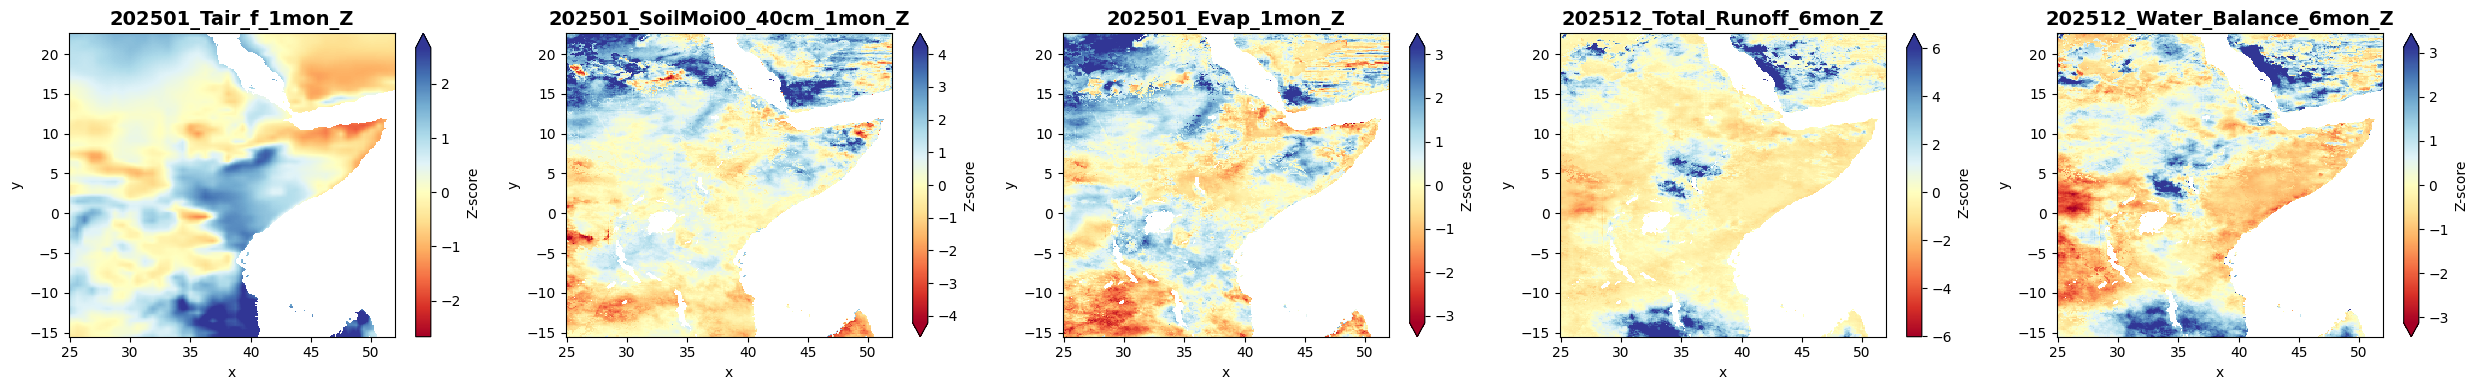

In [10]:
# --- [4] 시각화 검증 ---
with rioxarray.open_rasterio(target_file, masked=True) as da:
    da_masked = da.where(da != -9999)

    fig, axes = plt.subplots(1, 5, figsize=(25, 4))

    da_masked.isel(band=0).plot(ax=axes[0], cmap='RdYlBu', robust=True, cbar_kwargs={'label': 'Z-score'})
    axes[0].set_title(descriptions[0], fontsize=14, fontweight='bold')

    da_masked.isel(band=4).plot(ax=axes[1], cmap='RdYlBu', robust=True, cbar_kwargs={'label': 'Z-score'})
    axes[1].set_title(descriptions[4], fontsize=14, fontweight='bold')

    da_masked.isel(band=6).plot(ax=axes[2], cmap='RdYlBu', robust=True, cbar_kwargs={'label': 'Z-score'})
    axes[2].set_title(descriptions[6], fontsize=14, fontweight='bold')

    da_masked.isel(band=-2).plot(ax=axes[3], cmap='RdYlBu', robust=True, cbar_kwargs={'label': 'Z-score'})
    axes[3].set_title(descriptions[-2], fontsize=14, fontweight='bold')

    da_masked.isel(band=-1).plot(ax=axes[4], cmap='RdYlBu', robust=True, cbar_kwargs={'label': 'Z-score'})
    axes[4].set_title(descriptions[-1], fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [11]:
# 1. 경로 설정
# 최종 목적지인 공유 폴더(바로가기) 경로 (경로를 정확히 맞춰주세요)
target_dir = '/content/drive/MyDrive/WFP Collab/subnational_price_prediction/data/fldas/raw'

print(f"🚀 파일 이동을 시작합니다: {source_dir} -> {target_dir}")

# 목적지 폴더가 없다면 생성
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# 2. 파일 찾기 및 이동
# tif 파일들을 찾아서 하나씩 이동
tiff_files = glob.glob(os.path.join(source_dir, f"{EXPORT_DESC}_*.tif"))

if not tiff_files:
    print("⚠️ 이동할 파일이 없습니다. (GEE 다운로드가 완료되었는지 확인하세요)")
else:
    for file_path in tiff_files:
        file_name = os.path.basename(file_path)
        dest_path = os.path.join(target_dir, file_name)

        # 파일 이동 (잘라내기 & 붙여넣기)
        shutil.move(file_path, dest_path)
        print(f"✅ 이동 완료: {file_name}")

    print("\n🎉 모든 파일이 공유 폴더로 성공적으로 이동되었습니다!")

🚀 파일 이동을 시작합니다: /content/drive/MyDrive/GEE_EXPORTS -> /content/drive/MyDrive/WFP Collab/subnational_price_prediction/data/fldas/raw
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2007.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2008.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2009.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2010.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2011.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2013.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2012.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2014.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2016.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2015.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2017.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2019.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2018.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2020.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2022.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2021.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2024.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2025.tif
✅ 이동 완료: EastAfrica_FLDAS_Fixed_2023.tif

🎉 모든 파일이 공유 폴더로 성공적으로 이동되었습니다!
